In [ ]:
class WhyyTorch:
    
    def __init__(self, data, grad=0, _op="", children=(), label=None):
        self.data = data
        self.grad = grad
        self.op = _op
        self.children = set(children)
        self.label = label

    def __repr__(self):
        return f"Value: {self.data} Grad: {self.grad} Op:{self.op} children:{self.children}"

    def _coerce(self, other):
        return other if isinstance(other, MyTorch) else MyTorch(other)

    def __add__(self, other):
        other = self._coerce(other)
        x = MyTorch(self.data + other.data, _op="+", children=(self, other))
        def backward():
            self.grad += x.grad
            other.grad += x.grad
        x._backward = backward
        return x

    def __sub__(self, other):
        other = self._coerce(other)
        x = MyTorch(self.data - other.data, _op="-", children=(self, other))
        def backward():
            self.grad += x.grad
            other.grad += x.grad
        x._backward = backward
        return x

    def __mul__(self, other):
        other = self._coerce(other)
        x = MyTorch(self.data * other.data, _op="*", children=(self, other))
        def backward():
            self.grad += other.data * x.grad
            other.grad += self.data * x.grad
        x._backward = backward
        return x

    def __truediv__(self, other):
        other = self._coerce(other)
        x = MyTorch(self.data / other.data, _op="/", children=(self, other))
        def backward():
            self.grad += (1/other.data) * x.grad
            other.grad += (-self.data / (other.data ** 2)) * x.grad
        x._backward = backward
        return x
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for v in reversed(topo):
            if hasattr(v, '_backward'):
                v._backward()


In [ ]:
h = MyTorch(0.001)
a = MyTorch(2.0) ; a.label = "a"
b = MyTorch(3.0) ; b.label = "b"
d = MyTorch(4.0) ; d.label = "d"
x = MyTorch(5.0) ; x.label = "x"
y = MyTorch(6.0) ; y.label = "y"
c = (a + b)  + (x/y) ; c.label = "c" 
e = c * d ; e.label = "e"



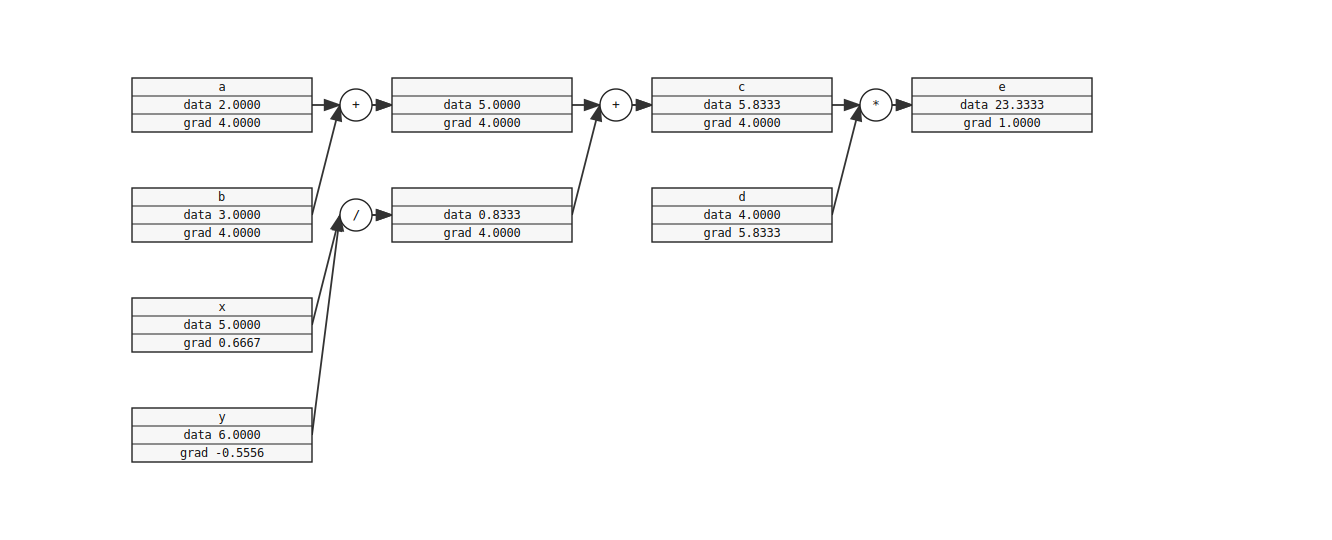

In [41]:
e.backward()
draw_dot(e)

In [19]:
from IPython.display import SVG
import html


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in sorted(v.children, key=id):
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def _layout_lr(root):
    # Compute depth from output; render leaves on the left and output on the right.
    depth = {}
    queue = [(root, 0)]
    while queue:
        node, d = queue.pop(0)
        if node in depth and depth[node] <= d:
            continue
        depth[node] = d
        for child in node.children:
            queue.append((child, d + 1))

    max_depth = max(depth.values(), default=0)

    levels = {}
    for n, d in depth.items():
        x_level = max_depth - d
        levels.setdefault(x_level, []).append(n)

    for lvl in levels:
        levels[lvl] = sorted(levels[lvl], key=lambda x: str(getattr(x, "label", "")) + str(id(x)))

    pos = {}
    x_spacing = 260
    y_spacing = 110
    margin_x = 70
    margin_y = 50

    max_rows = max((len(v) for v in levels.values()), default=1)
    width = margin_x * 2 + (max_depth + 1) * x_spacing
    height = margin_y * 2 + max_rows * y_spacing

    for x_level, row in levels.items():
        for i, node in enumerate(row):
            x = margin_x + x_level * x_spacing
            y = margin_y + (i + 0.5) * y_spacing
            pos[node] = (x, y)

    return pos, width, height


def draw_dot(root):
    nodes, edges = trace(root)
    pos, width, height = _layout_lr(root)

    val_w, val_h = 180, 54
    op_r = 16
    op_gap = 36

    # Add left padding so op-node of the leftmost value is never clipped.
    x_shift = val_w / 2 + op_gap + op_r + 10
    width = width + x_shift

    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{int(width)}' height='{int(height)}' viewBox='0 0 {int(width)} {int(height)}'>",
        "<defs><marker id='arrow' markerWidth='10' markerHeight='7' refX='9' refY='3.5' orient='auto'><polygon points='0 0, 10 3.5, 0 7' fill='#333'/></marker></defs>",
        "<rect width='100%' height='100%' fill='white'/>",
    ]

    # Edges: child -> op -> value (Karpathy style)
    for child, parent in edges:
        cx, cy = pos[child]
        px, py = pos[parent]

        cx += x_shift
        px += x_shift

        if parent.op:
            opx, opy = px - (val_w / 2 + op_gap), py
            parts.append(
                f"<line x1='{cx + val_w/2:.1f}' y1='{cy:.1f}' x2='{opx - op_r:.1f}' y2='{opy:.1f}' stroke='#333' stroke-width='1.8' marker-end='url(#arrow)'/>"
            )
            parts.append(
                f"<line x1='{opx + op_r:.1f}' y1='{opy:.1f}' x2='{px - val_w/2:.1f}' y2='{py:.1f}' stroke='#333' stroke-width='1.8' marker-end='url(#arrow)'/>"
            )
        else:
            parts.append(
                f"<line x1='{cx + val_w/2:.1f}' y1='{cy:.1f}' x2='{px - val_w/2:.1f}' y2='{py:.1f}' stroke='#333' stroke-width='1.8' marker-end='url(#arrow)'/>"
            )

    # Value nodes
    for n in nodes:
        x, y = pos[n]
        x += x_shift
        x0, y0 = x - val_w / 2, y - val_h / 2
        label = html.escape(str(getattr(n, 'label', '') or ''))
        data_text = html.escape(f"data {n.data:.4f}")
        grad_text = html.escape(f"grad {n.grad:.4f}")

        parts.append(f"<rect x='{x0:.1f}' y='{y0:.1f}' width='{val_w}' height='{val_h}' fill='#f7f7f7' stroke='#222' stroke-width='1.4'/>")
        parts.append(f"<line x1='{x0:.1f}' y1='{y0 + 18:.1f}' x2='{x0 + val_w:.1f}' y2='{y0 + 18:.1f}' stroke='#222' stroke-width='1'/>")
        parts.append(f"<line x1='{x0:.1f}' y1='{y0 + 36:.1f}' x2='{x0 + val_w:.1f}' y2='{y0 + 36:.1f}' stroke='#222' stroke-width='1'/>")

        parts.append(f"<text x='{x:.1f}' y='{y0 + 13:.1f}' text-anchor='middle' font-family='Consolas, monospace' font-size='12' fill='#111'>{label}</text>")
        parts.append(f"<text x='{x:.1f}' y='{y0 + 31:.1f}' text-anchor='middle' font-family='Consolas, monospace' font-size='12' fill='#111'>{data_text}</text>")
        parts.append(f"<text x='{x:.1f}' y='{y0 + 49:.1f}' text-anchor='middle' font-family='Consolas, monospace' font-size='12' fill='#111'>{grad_text}</text>")

        if n.op:
            opx, opy = x - (val_w / 2 + op_gap), y
            op_text = html.escape(n.op)
            parts.append(f"<circle cx='{opx:.1f}' cy='{opy:.1f}' r='{op_r}' fill='white' stroke='#222' stroke-width='1.4'/>")
            parts.append(f"<text x='{opx:.1f}' y='{opy + 4:.1f}' text-anchor='middle' font-family='Consolas, monospace' font-size='13' fill='#111'>{op_text}</text>")

    parts.append("</svg>")
    return SVG("".join(parts))